# 05 — Modelo Híbrido (CNN + MLP)
### GalaxyNet — Classificador Morfológico de Galáxias

Modelo de fusão tardia (*late fusion*) que combina:
- **Branch CNN**: imagens $(64 \times 64 \times 3)$ nas bandas $g$, $r$, $i$ — extrai features espaciais
- **Branch MLP**: 15 features tabulares fotométricas — captura propriedades globais

As representações são concatenadas e processadas por uma cabeça de classificação densa.
Inclui Data Augmentation, Class Weights e visualização **Grad-CAM** para interpretabilidade.

In [1]:
import sys
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

def _find_src_dir():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        candidate = os.path.join(current, 'src')
        if os.path.isdir(candidate):
            return candidate
        current = os.path.dirname(current)
    raise RuntimeError("Diretório src/ não encontrado.")

src_path = _find_src_dir()
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

from preprocessing import load_preprocessed_images, load_preprocessed_tabular
from models import create_hybrid_model
from evaluation import evaluate_galaxy_classifier
from visualization import compute_gradcam_hybrid, plot_gradcam_grid

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Caminhos
_project_root = os.path.dirname(src_path)
PROCESSED_DIR = os.path.join(_project_root, 'data', 'processed')
MODELS_DIR    = os.path.join(_project_root, 'models')
REPORTS_DIR   = os.path.join(_project_root, 'reports', 'figures')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"TensorFlow    : {tf.__version__}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"MODELS_DIR    : {MODELS_DIR}")

I0000 00:00:1776219247.297050   22486 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776219247.332672   22486 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776219248.526713   22486 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow    : 2.21.0
PROCESSED_DIR : /home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed
MODELS_DIR    : /home/luciano/Documentos/GalaxyNet/galaxy_classification/models


---
## 1. Carregamento dos Dados

Carrega os dados tabulares (15 features normalizadas) e as imagens pré-processadas.
Alinha ambos por `objid` para garantir correspondência correta.

In [2]:
# Carregar dados tabulares BRUTOS (sem escalonamento)
X_tabular_raw, y_labels_tab, tab_objids, _ = load_preprocessed_tabular(PROCESSED_DIR)

# Carregar imagens pré-processadas
X_images, img_objids = load_preprocessed_images(PROCESSED_DIR)

# Alinhar por objid (interseção)
common_objids = np.intersect1d(tab_objids, img_objids)
tab_idx = np.array([np.where(tab_objids == oid)[0][0] for oid in common_objids])
img_idx = np.array([np.where(img_objids == oid)[0][0] for oid in common_objids])

X_tabular_raw = X_tabular_raw[tab_idx]
X_images      = X_images[img_idx]
y_labels      = y_labels_tab[tab_idx]
objids        = common_objids

print(f"X_tabular_raw   : {X_tabular_raw.shape}  dtype={X_tabular_raw.dtype}  (bruto, pré-escalonamento)")
print(f"X_images        : {X_images.shape}  dtype={X_images.dtype}")
print(f"y_labels        : {y_labels.shape}")
print(f"Imagens [0,1]   : min={X_images.min():.4f}, max={X_images.max():.4f}")

print("\nDistribuição de classes:")
unique, counts = np.unique(y_labels, return_counts=True)
for cls, n in zip(unique, counts):
    print(f"  {cls:<12}: {n:>4} ({100*n/len(y_labels):.1f}%)")

Carregado de '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_tabular : (9054, 15)
  y_labels  : 9054 rótulos
  objids    : 9054 IDs
Carregado de '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_images   : (9054, 64, 64, 3)
  img_objids : 9054 IDs
X_tabular_raw   : (9054, 15)  dtype=float32  (bruto, pré-escalonamento)
X_images        : (9054, 64, 64, 3)  dtype=float32
y_labels        : (9054,)
Imagens [0,1]   : min=0.0000, max=1.0000

Distribuição de classes:
  Elliptical  : 7595 (83.9%)
  Irregular   :  261 (2.9%)
  Spiral      : 1198 (13.2%)


---
## 2. Encoding de Labels e Split Train/Val/Test

Carrega o `LabelEncoder` do notebook 03 para manter consistência entre modelos.
Split estratificado 70/15/15 aplicado simultaneamente aos dados tabulares e imagens.

In [3]:
# Carregar LabelEncoder do notebook 03 para consistência
le_path = os.path.join(MODELS_DIR, 'label_encoder.pkl')
if os.path.exists(le_path):
    with open(le_path, 'rb') as f:
        label_encoder = pickle.load(f)
    print(f"LabelEncoder carregado de: {le_path}")
else:
    label_encoder = LabelEncoder()
    label_encoder.fit(y_labels)
    print("LabelEncoder ajustado localmente (label_encoder.pkl não encontrado)")

y_encoded = label_encoder.transform(y_labels)
y_one_hot = to_categorical(y_encoded)

num_classes = y_one_hot.shape[1]
print(f"Classes: {list(label_encoder.classes_)} → {list(range(num_classes))}")

# Split estratificado: 70% train, 15% val, 15% test (mesmo SEED do notebook 03)
indices = np.arange(len(y_labels))
idx_train, idx_temp = train_test_split(
    indices, test_size=0.30, random_state=SEED, stratify=y_encoded
)

y_temp_encoded = y_encoded[idx_temp]
_, temp_counts = np.unique(y_temp_encoded, return_counts=True)
use_stratify = temp_counts.min() >= 2

idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=SEED,
    stratify=y_temp_encoded if use_stratify else None
)

if not use_stratify:
    print("⚠ Classes minoritárias com <2 amostras no temp — segundo split sem stratify")

# Indexar dados brutos e imagens
X_tab_train_raw = X_tabular_raw[idx_train]
X_tab_val_raw   = X_tabular_raw[idx_val]
X_tab_test_raw  = X_tabular_raw[idx_test]

X_img_train, X_img_val, X_img_test = X_images[idx_train], X_images[idx_val], X_images[idx_test]
y_train, y_val, y_test = y_one_hot[idx_train], y_one_hot[idx_val], y_one_hot[idx_test]
objids_train, objids_val, objids_test = objids[idx_train], objids[idx_val], objids[idx_test]

# Aplicar scaler ajustado no treino do notebook 03 (evita re-fitting e leakage)
scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)
print(f"\nScaler carregado de: {scaler_path}")

X_tab_train = scaler.transform(X_tab_train_raw).astype(np.float32)
X_tab_val   = scaler.transform(X_tab_val_raw).astype(np.float32)
X_tab_test  = scaler.transform(X_tab_test_raw).astype(np.float32)

print(f"\nTrain : {len(idx_train)} amostras")
print(f"Val   : {len(idx_val)} amostras")
print(f"Test  : {len(idx_test)} amostras")
print(f"  Tabular shape: train={X_tab_train.shape}, val={X_tab_val.shape}, test={X_tab_test.shape}")
print(f"  Image shape  : train={X_img_train.shape}, val={X_img_val.shape}, test={X_img_test.shape}")

for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    labels = label_encoder.inverse_transform(np.argmax(y_split, axis=1))
    unique, counts = np.unique(labels, return_counts=True)
    dist = ', '.join(f"{c}:{n}" for c, n in zip(unique, counts))
    print(f"  {name}: {dist}")

LabelEncoder carregado de: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/label_encoder.pkl
Classes: ['Elliptical', 'Irregular', 'Spiral'] → [0, 1, 2]

Scaler carregado de: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/scaler.pkl

Train : 6337 amostras
Val   : 1358 amostras
Test  : 1359 amostras
  Tabular shape: train=(6337, 15), val=(1358, 15), test=(1359, 15)
  Image shape  : train=(6337, 64, 64, 3), val=(1358, 64, 64, 3), test=(1359, 64, 64, 3)
  Train: Elliptical:5316, Irregular:183, Spiral:838
  Val: Elliptical:1139, Irregular:39, Spiral:180
  Test: Elliptical:1140, Irregular:39, Spiral:180


In [4]:
# ───────────────────────────────────────────────────────────────────────────
# SMOTE oversampling (hibrido) — balanceia as classes APENAS no TREINO.
# Concatenamos features tabulares (15) + imagem achatada (64*64*3=12288) em
# um unico vetor, aplicamos SMOTE, e depois separamos de volta nos dois ramos.
# Val/test permanecem intactos.
# ───────────────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from collections import Counter

n_train_before = X_tab_train.shape[0]
tab_dim   = X_tab_train.shape[1]                    # 15
img_shape = X_img_train.shape[1:]                   # (64, 64, 3)

X_img_train_flat = X_img_train.reshape(n_train_before, -1)
X_concat_train   = np.concatenate([X_tab_train, X_img_train_flat], axis=1)
y_train_int      = np.argmax(y_train, axis=1)

counts_before = Counter(y_train_int)
n_min = min(counts_before.values())
k_nn  = max(1, min(5, n_min - 1))
print(f"Distribuicao antes do SMOTE: {dict(counts_before)}  (k_neighbors={k_nn})")

smote = SMOTE(random_state=SEED, k_neighbors=k_nn)
X_concat_res, y_train_int_res = smote.fit_resample(X_concat_train, y_train_int)

# Separar de volta nos dois ramos
X_tab_train = X_concat_res[:, :tab_dim].astype(np.float32)
X_img_train = np.clip(X_concat_res[:, tab_dim:], 0.0, 1.0) \
                .reshape(-1, *img_shape).astype(np.float32)
y_train     = to_categorical(y_train_int_res, num_classes=num_classes)

counts_after = Counter(y_train_int_res)
print(f"Distribuicao depois do SMOTE: {dict(counts_after)}")
print(f"Train pos-SMOTE: {X_tab_train.shape[0]} amostras (antes: {n_train_before})")
print(f"  X_tab_train: {X_tab_train.shape}")
print(f"  X_img_train: {X_img_train.shape}")


Distribuicao antes do SMOTE: {np.int64(0): 5419, np.int64(2): 862, np.int64(1): 186}  (k_neighbors=5)
Distribuicao depois do SMOTE: {np.int64(0): 5419, np.int64(2): 5419, np.int64(1): 5419}
Train pos-SMOTE: 16257 amostras (antes: 6467)
  X_tab_train: (16257, 15)
  X_img_train: (16257, 64, 64, 3)


---
## 3. Data Augmentation e Class Weights

Data augmentation é aplicada apenas nas imagens (branch CNN). As features tabulares
passam diretamente sem transformação. Um gerador customizado `hybrid_generator`
combina ambas as entradas para o modelo dual-input.

- **Rotação 360°**, flips horizontal/vertical, zoom 0.2, brightness [0.8, 1.2]
- `fill_mode='constant'` com `cval=0.0` (fundo = céu escuro)

In [4]:
# Data augmentation — apenas para imagens
# (sem brightness_range: imagens ja estao min-max normalizadas em [0,1],
# e brightness shift desestabiliza as estatisticas do BatchNorm)
datagen = ImageDataGenerator(
    rotation_range=360,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    fill_mode='constant',
    cval=0.0,
)

# Apos SMOTE, o treino ja esta balanceado — usamos pesos uniformes (1.0)
# para evitar dupla compensacao de desbalanceamento.
y_train_integers = np.argmax(y_train, axis=1)
class_weight_dict = {i: 1.0 for i in range(num_classes)}

print("Class weights (uniformes apos SMOTE):")
for idx, weight in class_weight_dict.items():
    cls_name = label_encoder.inverse_transform([idx])[0]
    n_train = (y_train_integers == idx).sum()
    print(f"  {cls_name:<12} (idx={idx}): weight={weight:.3f}  (n_train={n_train})")

def make_hybrid_dataset(X_tab, X_img, y, datagen, class_weight_dict, batch_size=32):
    """
    Cria um tf.data.Dataset que aplica data augmentation nas imagens e
    incorpora class weights como sample weights.
    """
    tab_shape = X_tab.shape[1:]
    img_shape = X_img.shape[1:]
    n_classes = y.shape[1]

    def gen():
        while True:
            indices = np.random.permutation(len(y))
            for start in range(0, len(y), batch_size):
                end = min(start + batch_size, len(y))
                batch_idx = indices[start:end]

                tab_batch = X_tab[batch_idx]
                img_batch = X_img[batch_idx]
                y_batch = y[batch_idx]

                sample_weights = np.array([
                    class_weight_dict[np.argmax(label)] for label in y_batch
                ], dtype=np.float32)

                aug_imgs = np.zeros_like(img_batch)
                for k in range(len(img_batch)):
                    aug_imgs[k] = datagen.random_transform(img_batch[k])

                yield (tab_batch, aug_imgs), y_batch, sample_weights

    output_signature = (
        (tf.TensorSpec(shape=(None,) + tab_shape, dtype=tf.float32),
         tf.TensorSpec(shape=(None,) + img_shape, dtype=tf.float32)),
        tf.TensorSpec(shape=(None, n_classes), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )

    dataset = tf.data.Dataset.from_generator(gen, output_signature=output_signature)
    return dataset

# Steps por época (recalculado apos SMOTE)
BATCH_SIZE = 32
steps_per_epoch = max(1, len(y_train) // BATCH_SIZE)
print(f"\nBatch size: {BATCH_SIZE}, Steps/epoch: {steps_per_epoch}")


Class weights (uniformes apos SMOTE):
  Elliptical   (idx=0): weight=1.000  (n_train=5316)
  Irregular    (idx=1): weight=1.000  (n_train=183)
  Spiral       (idx=2): weight=1.000  (n_train=838)

Batch size: 32, Steps/epoch: 198


---
## 4. Criação do Modelo Híbrido

Arquitetura Functional API com dois inputs (tabular + imagem) → fusão por concatenação.

In [5]:
tabular_shape = X_tab_train.shape[1]  # 15
image_shape = X_img_train.shape[1:]   # (64, 64, 3)

hybrid_model = create_hybrid_model(tabular_shape, image_shape, num_classes)
hybrid_model.summary()

E0000 00:00:1776219282.383102   22486 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776219282.383583   22633 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776219282.405809   22486 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "hybrid_galaxy_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 8, 128) │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 4, 4, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,493,251 (5.70 MB)

 Trainable params: 1,491,139 (5.69 MB)

 Non-trainable params: 2,112 (8.25 KB)

---
## 5. Treinamento

O treinamento usa o `hybrid_generator` para aplicar data augmentation nas imagens
enquanto passa as features tabulares diretamente. A validação usa dados originais.

- **EarlyStopping**: patience=15, restaura melhores pesos
- **ReduceLROnPlateau**: reduz LR pela metade se val_loss estagnar por 7 épocas

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-7, verbose=1
    ),
]

train_dataset = make_hybrid_dataset(X_tab_train, X_img_train, y_train, datagen,
                                    class_weight_dict, BATCH_SIZE)

history = hybrid_model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=([X_tab_val, X_img_val], y_val),
    epochs=100,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nTreinamento finalizado em {len(history.history['loss'])} épocas.")

Epoch 1/100


I0000 00:00:1776219287.758114   22486 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6148 - loss: 1.1179

W0000 00:00:1776219314.331995   22486 cpu_allocator_impl.cc:82] Allocation of 66748416 exceeds 10% of free system memory.


198/198 ━━━━━━━━━━━━━━━━━━━━ 28s 124ms/step - accuracy: 0.7360 - loss: 0.7998 - val_accuracy: 0.8608 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.8944 - loss: 0.3713 - val_accuracy: 0.8859 - val_loss: 0.4599 - learning_rate: 0.0010
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9098 - loss: 0.2935 - val_accuracy: 0.9050 - val_loss: 0.3803 - learning_rate: 0.0010
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9145 - loss: 0.2780 - val_accuracy: 0.9131 - val_loss: 0.3217 - learning_rate: 0.0010
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9218 - loss: 0.2420 - val_accuracy: 0.9345 - val_loss: 0.2339 - learning_rate: 0.0010
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - accuracy: 0.9255 - loss: 0.2288 - val_accuracy: 0.9256 - val_loss: 0.2432 - learning_rate: 0.0010
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9212 -

---
## 6. Curvas de Treinamento (Loss e Accuracy)

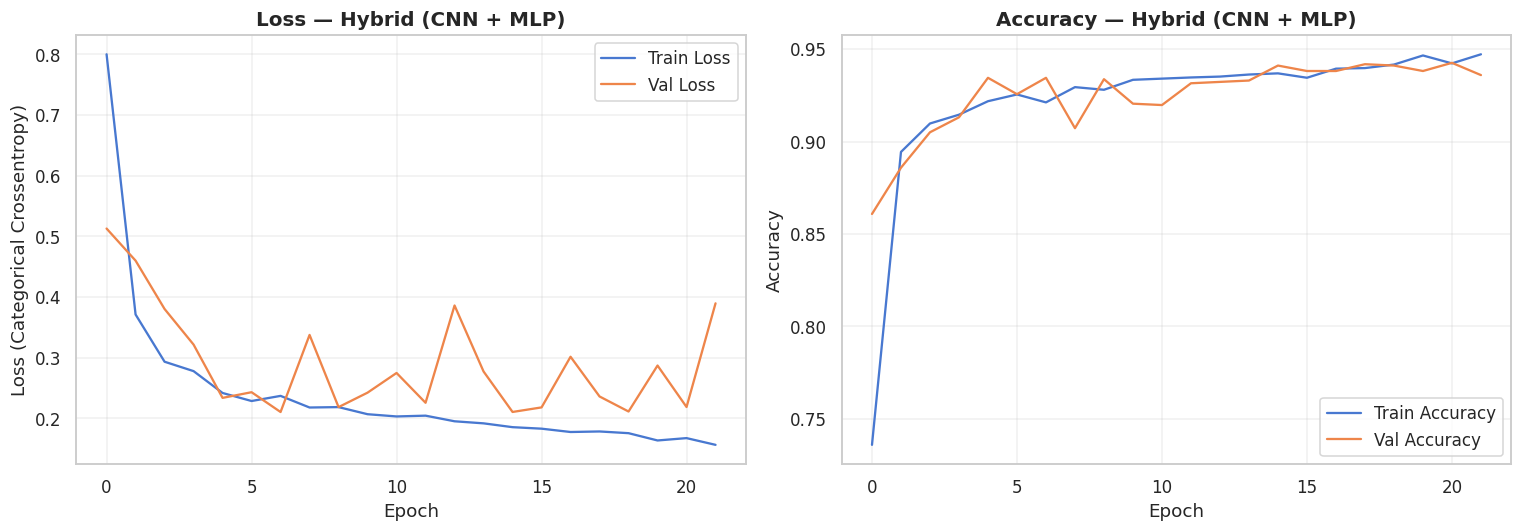

Figura salva: fig20_hybrid_training_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss — Hybrid (CNN + MLP)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy — Hybrid (CNN + MLP)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig20_hybrid_training_curves.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig20_hybrid_training_curves.png')

---
## 7. Avaliação no Conjunto de Teste

W0000 00:00:1776219902.753569   22486 cpu_allocator_impl.cc:82] Allocation of 66797568 exceeds 10% of free system memory.


Hybrid Test Loss: 0.1947, Test Accuracy: 0.9308


W0000 00:00:1776219903.684806   22486 cpu_allocator_impl.cc:82] Allocation of 66797568 exceeds 10% of free system memory.



--- Evaluation for Hybrid Model ---

Classification Report:
              precision    recall  f1-score   support

  Elliptical       0.97      0.97      0.97      1140
   Irregular       0.75      0.23      0.35        39
      Spiral       0.74      0.82      0.78       180

    accuracy                           0.93      1359
   macro avg       0.82      0.67      0.70      1359
weighted avg       0.93      0.93      0.93      1359


Confusion matrix salva em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/reports/figures/fig17_hybrid_confusion_matrix.png


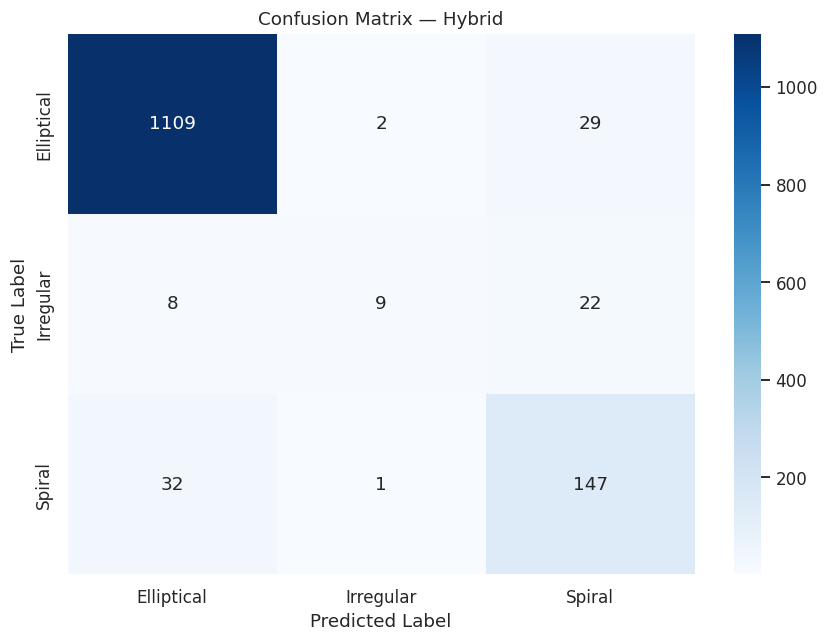


Scientific Metrics (Completeness and Reliability per Class):
     Class  N_True Completeness (Recall) Reliability (Precision)
Elliptical    1140                 0.973                   0.965
 Irregular      39                 0.231                   0.750
    Spiral     180                 0.817                   0.742


In [8]:
loss, accuracy = hybrid_model.evaluate([X_tab_test, X_img_test], y_test, verbose=0)
print(f"Hybrid Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

eval_results = evaluate_galaxy_classifier(
    model=hybrid_model,
    X_test_data=[X_tab_test, X_img_test],
    y_test_one_hot=y_test,
    label_encoder=label_encoder,
    model_type='Hybrid',
    save_dir=REPORTS_DIR,
)

---
## 8. Grad-CAM — Interpretabilidade

Grad-CAM (Gradient-weighted Class Activation Mapping) destaca as regiões da imagem
que mais contribuíram para a decisão do modelo. Aplicamos na última camada convolucional
do branch CNN do modelo híbrido.

Isso permite verificar se o modelo foca em características astrofísicas relevantes:
- **Elípticas**: distribuição de luz suave e centralizada
- **Espirais**: braços espirais e regiões de formação estelar
- **Irregulares**: estrutura assimétrica e clumpy

Última camada convolucional: conv2d_3
Grad-CAM figure salva em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/reports/figures/fig21_hybrid_gradcam.png


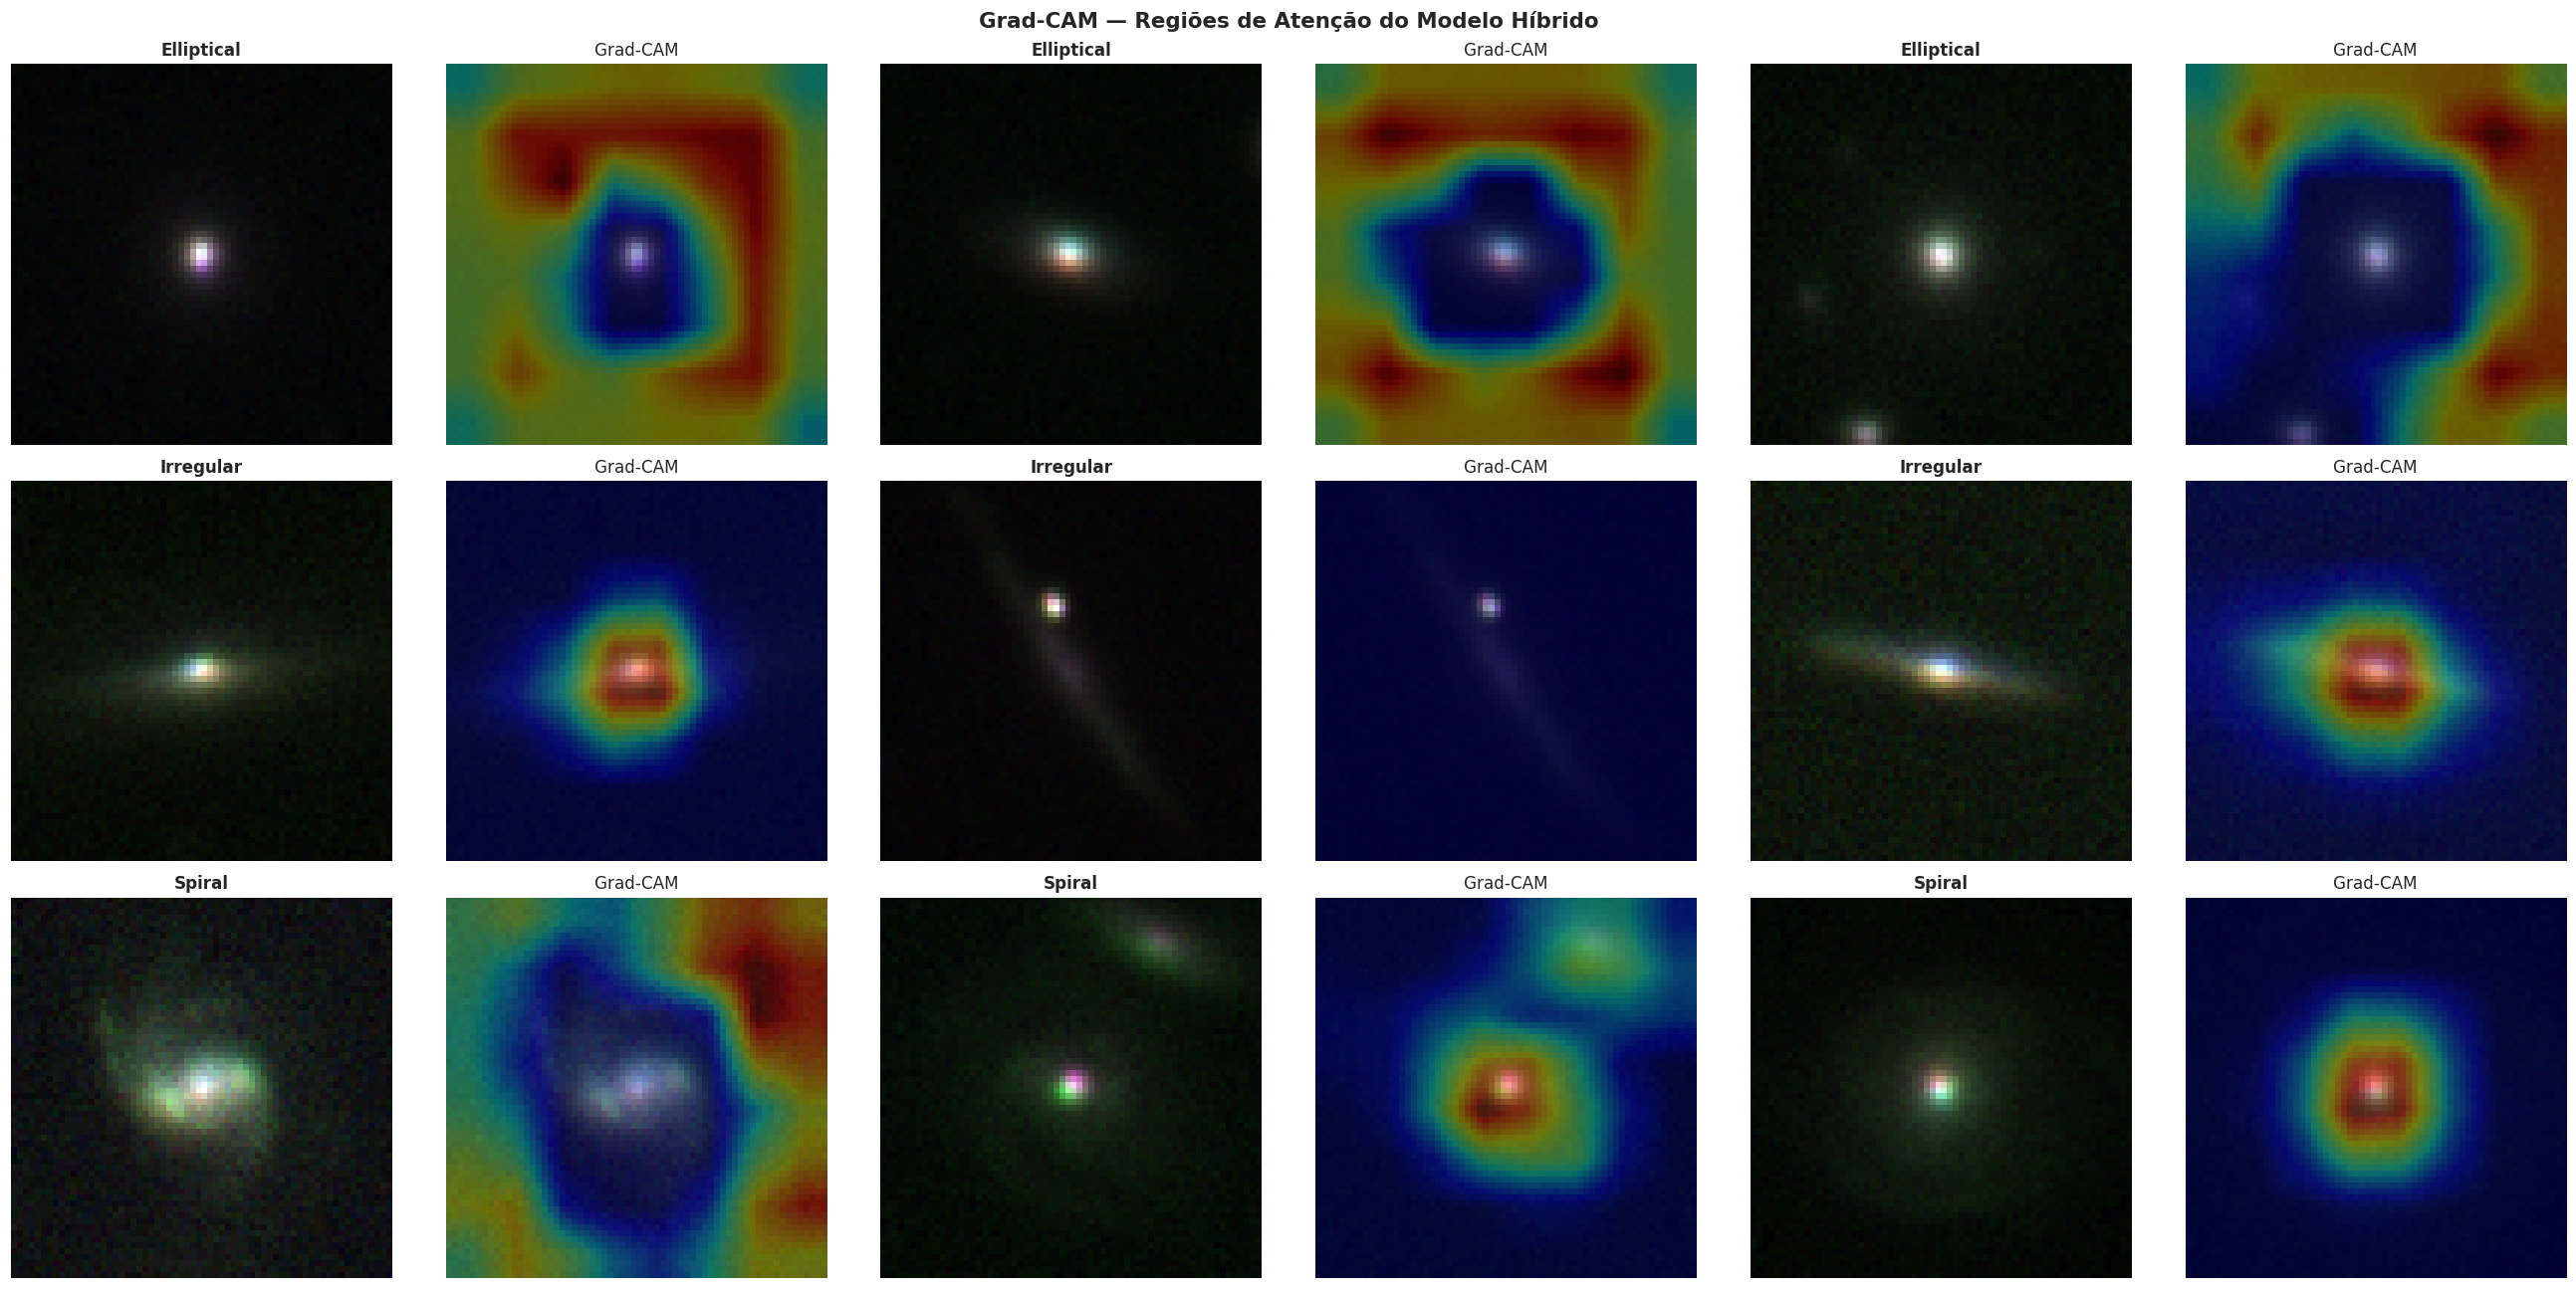

In [9]:
# Identificar a última camada convolucional do branch CNN
conv_layers = [layer.name for layer in hybrid_model.layers
               if isinstance(layer, keras.layers.Conv2D)]
last_conv_layer = conv_layers[-1]
print(f"Última camada convolucional: {last_conv_layer}")

# Labels verdadeiros do conjunto de teste
y_test_labels = label_encoder.inverse_transform(np.argmax(y_test, axis=1))

# Gerar grid de Grad-CAM
fig = plot_gradcam_grid(
    model=hybrid_model,
    X_tabular=X_tab_test,
    X_images=X_img_test,
    y_true_labels=y_test_labels,
    layer_name=last_conv_layer,
    label_encoder=label_encoder,
    n_per_class=3,
    save_path=os.path.join(REPORTS_DIR, 'fig21_hybrid_gradcam.png'),
)
plt.show()

---
## 9. Salvar Modelo e Artefatos

In [10]:
# Salvar modelo treinado
model_path = os.path.join(MODELS_DIR, 'hybrid_galaxy_classifier.h5')
hybrid_model.save(model_path)
print(f"Modelo salvo em: {model_path}")

# Salvar dados de teste para comparação posterior entre modelos
test_artifacts = {
    'X_tab_test': X_tab_test,
    'X_img_test': X_img_test,
    'y_test': y_test,
    'objids_test': objids_test,
}
test_path = os.path.join(MODELS_DIR, 'hybrid_test_data.pkl')
with open(test_path, 'wb') as f:
    pickle.dump(test_artifacts, f)
print(f"Dados de teste salvos em: {test_path}")

Modelo salvo em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/hybrid_galaxy_classifier.h5
Dados de teste salvos em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/hybrid_test_data.pkl


---
## 10. Resumo

In [11]:
print("=" * 60)
print("RESUMO — MODELO HÍBRIDO (CNN + MLP)")
print("=" * 60)
print(f"Input tabular        : {tabular_shape} features")
print(f"Input imagem         : {image_shape}")
print(f"Classes              : {list(label_encoder.classes_)}")
print(f"Amostras (train/val/test): {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")
print(f"Data augmentation    : rotation=360°, flips, zoom=0.2, brightness=[0.8,1.2]")
print(f"Épocas treinadas     : {len(history.history['loss'])}")
print(f"Test Loss            : {loss:.4f}")
print(f"Test Accuracy        : {accuracy:.4f}")
print()
print("Métricas Científicas:")
print(eval_results['scientific_metrics'].to_string(index=False))
print()
print("Artefatos salvos:")
print(f"  1. {model_path}")
print(f"  2. {test_path}")
print(f"  3. reports/figures/fig20_hybrid_training_curves.png")
print(f"  4. reports/figures/fig17_hybrid_confusion_matrix.png")
print(f"  5. reports/figures/fig21_hybrid_gradcam.png")

RESUMO — MODELO HÍBRIDO (CNN + MLP)
Input tabular        : 15 features
Input imagem         : (64, 64, 3)
Classes              : ['Elliptical', 'Irregular', 'Spiral']
Amostras (train/val/test): 6337/1358/1359
Data augmentation    : rotation=360°, flips, zoom=0.2, brightness=[0.8,1.2]
Épocas treinadas     : 22
Test Loss            : 0.1947
Test Accuracy        : 0.9308

Métricas Científicas:
     Class  N_True Completeness (Recall) Reliability (Precision)
Elliptical    1140                 0.973                   0.965
 Irregular      39                 0.231                   0.750
    Spiral     180                 0.817                   0.742

Artefatos salvos:
  1. /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/hybrid_galaxy_classifier.h5
  2. /home/luciano/Documentos/GalaxyNet/galaxy_classification/models/hybrid_test_data.pkl
  3. reports/figures/fig20_hybrid_training_curves.png
  4. reports/figures/fig17_hybrid_confusion_matrix.png
  5. reports/figures/fig21_hybr